#Import Libraries

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,confusion_matrix, roc_auc_score,
    roc_curve)
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## Load and Explore Data

In [ ]:

df = pd.read_csv('cleaned_merged_heart_dataset.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1888, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1888 entries, 0 to 1887
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1888 non-null   int64  
 1   sex       1888 non-null   int64  
 2   cp        1888 non-null   int64  
 3   trestbps  1888 non-null   int64  
 4   chol      1888 non-null   int64  
 5   fbs       1888 non-null   int64  
 6   restecg   1888 non-null   int64  
 7   thalachh  1888 non-null   int64  
 8   exang     1888 non-null   int64  
 9   oldpeak   1888 non-null   float64
 10  slope     1888 non-null   int64  
 11  ca        1888 non-null   int64  
 12  thal      1888 non-null   int64  
 13  target    1888 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 206.6 KB


# Check for missing values

In [ ]:
print("Missing values:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalachh    0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total missing: 0


## Data Cleaning

In [ ]:
# Convert to numeric
df = df.apply(pd.to_numeric, errors='coerce')

# Drop columns with all NaN
df = df.dropna(axis=1, how='all')

print(f"Shape after cleaning: {df.shape}")

Shape after cleaning: (1888, 14)


In [ ]:
# Check target variable
target_col = 'target'
print(f"Target column: {target_col}")
print(f"Unique values: {df[target_col].unique()}")
print(f"\nValue counts:")
print(df[target_col].value_counts())

Target column: target
Unique values: [1 0]

Value counts:
target
1    977
0    911
Name: count, dtype: int64


# Convert target to binary (0 = no disease, 1 = disease)


In [ ]:
df[target_col] = (df[target_col] > 0).astype(int)

print("Target distribution after conversion:")
print(df[target_col].value_counts())
print(f"\nClass balance: {df[target_col].value_counts(normalize=True) * 100}%")

Target distribution after conversion:
target
1    977
0    911
Name: count, dtype: int64

Class balance: target
1    51.747881
0    48.252119
Name: proportion, dtype: float64%


##  Prepare Features and Target

> Add blockquote



In [ ]:
# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")

Features shape: (1888, 13)
Target shape: (1888,)

Feature columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalachh', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


## Split Data



In [ ]:
# First split: separate test set (20%)

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Second split: separate train and validation from temp (75% train, 25% val of temp)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25,  random_state=42, stratify=y_temp)

print("Data split:")
print(f"  Train:      {len(X_train):4d} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Validation: {len(X_val):4d} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"  Test:       {len(X_test):4d} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"  Total:      {len(X):4d} samples")

Data split:
  Train:      1132 samples (60.0%)
  Validation:  378 samples (20.0%)
  Test:        378 samples (20.0%)
  Total:      1888 samples


## Feature Scaling

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("✓ Features scaled successfully")
print(f"  Train mean: {X_train_scaled.mean():.6f}")
print(f"  Train std:  {X_train_scaled.std():.6f}")

✓ Features scaled successfully
  Train mean: -0.000000
  Train std:  1.000000


##  Train Baseline Model

In [ ]:
# Baseline model with reasonable hyperparameters
baseline_model = XGBClassifier(n_estimators=200,max_depth=4,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,eval_metric='logloss',random_state=42, early_stopping_rounds=20 )

#  Train with validation set (NOT test set!)
baseline_model.fit(X_train_scaled, y_train,eval_set=[(X_train_scaled, y_train), (X_val_scaled, y_val)], verbose=50)

print("\n Baseline model trained successfully")

[0]	validation_0-logloss:0.66699	validation_1-logloss:0.66640
[50]	validation_0-logloss:0.26875	validation_1-logloss:0.29125
[100]	validation_0-logloss:0.17600	validation_1-logloss:0.21688
[150]	validation_0-logloss:0.13477	validation_1-logloss:0.18809
[199]	validation_0-logloss:0.10912	validation_1-logloss:0.17176

 Baseline model trained successfully


## Evaluate Baseline Model

> Add blockquote



In [ ]:
# Predictions
y_train_pred = baseline_model.predict(X_train_scaled)
y_val_pred = baseline_model.predict(X_val_scaled)
y_test_pred = baseline_model.predict(X_test_scaled)

y_test_proba = baseline_model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
train_acc = accuracy_score(y_train, y_train_pred)
val_acc = accuracy_score(y_val, y_val_pred)
test_acc = accuracy_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_proba)

print("BASELINE MODEL RESULTS")

print(f"Train Accuracy:      {train_acc*100:6.2f}%")
print(f"Validation Accuracy: {val_acc*100:6.2f}%")
print(f"Test Accuracy:       {test_acc*100:6.2f}%")
print(f"Test AUC-ROC:        {test_auc:6.4f}")

print(f"Train-Val Gap:       {abs(train_acc - val_acc)*100:6.2f}%")
print(f"Train-Test Gap:      {abs(train_acc - test_acc)*100:6.2f}%")


# Check for overfitting
if train_acc - test_acc > 0.05:
    print("  WARNING: Possible overfitting detected!")
    print("   Train accuracy is significantly higher than test")
elif test_acc - train_acc > 0.02:
    print(" SUSPICIOUS: Test accuracy higher than train!")
    print("   This might indicate data leakage")
else:
    print(" Model looks healthy - no obvious overfitting")

BASELINE MODEL RESULTS
Train Accuracy:       98.23%
Validation Accuracy:  95.24%
Test Accuracy:        96.30%
Test AUC-ROC:        0.9903
Train-Val Gap:         3.00%
Train-Test Gap:        1.94%
 Model looks healthy - no obvious overfitting


In [ ]:
# Detailed classification report
print("\nClassification Report (Test Set):")
print(classification_report(
    y_test, y_test_pred,
    target_names=['No Disease', 'Disease'],
    digits=4))


Classification Report (Test Set):
              precision    recall  f1-score   support

  No Disease     0.9615    0.9615    0.9615       182
     Disease     0.9643    0.9643    0.9643       196

    accuracy                         0.9630       378
   macro avg     0.9629    0.9629    0.9629       378
weighted avg     0.9630    0.9630    0.9630       378



# Confusion Matrix


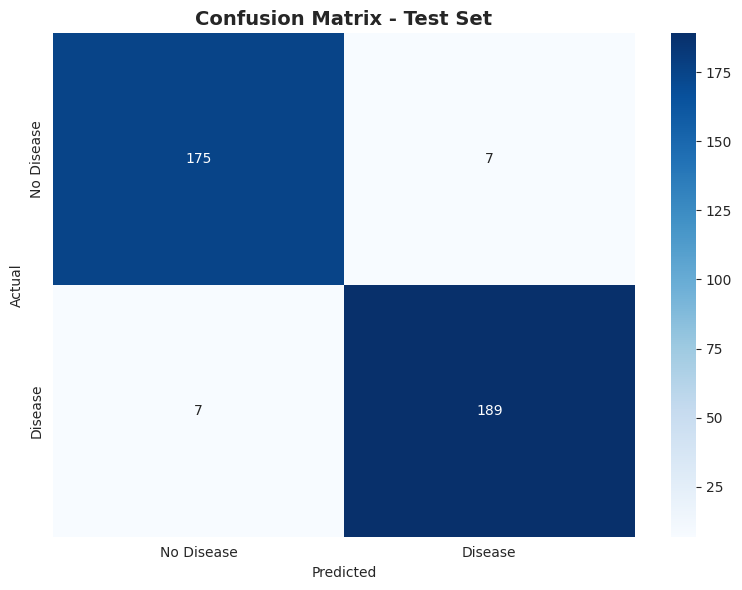

In [ ]:
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],yticklabels=['No Disease', 'Disease'])

plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

##  Cross-Validation Check

In [ ]:
# Cross-validation on training data only
cv_model = XGBClassifier(n_estimators=200,max_depth=4,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,eval_metric='logloss',random_state=42)

# Use StratifiedKFold for better results
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(cv_model, X_train_scaled, y_train, cv=cv,
    scoring='accuracy')

print("CROSS-VALIDATION RESULTS (5-Fold)")

print(f"CV Scores: {cv_scores}")
print(f"CV Mean:   {cv_scores.mean()*100:.2f}%")
print(f"CV Std:    ±{cv_scores.std()*100:.2f}%")
print(f"Test Acc:  {test_acc*100:.2f}%")

if cv_scores.std() > 0.05:
    print(" High variance in CV scores - model might be unstable")
else:
    print(" Low variance - model is stable across folds")

CROSS-VALIDATION RESULTS (5-Fold)
CV Scores: [0.94713656 0.91189427 0.93362832 0.93362832 0.89380531]
CV Mean:   92.40%
CV Std:    ±1.89%
Test Acc:  96.30%
 Low variance - model is stable across folds


##  Hyperparameter Tuning with Optuna

In [ ]:
# Install optuna if not already installed
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 6.6 MB/s eta 0:00:00


In [ ]:
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances

def objective(trial):

    params = {'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 2),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 2),
        'eval_metric': 'logloss',
        'random_state': 42,}

    model = XGBClassifier(**params)

    #  Use CV on TRAINING data only (not touching test set)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train_scaled, y_train,cv=cv, scoring='roc_auc')

    return scores.mean()

print("Starting hyperparameter optimization")
print("This may take several minutes\n")

Starting hyperparameter optimization
This may take several minutes



In [ ]:
# Create study and optimize
study = optuna.create_study(direction='maximize', study_name='heart_disease')
study.optimize(objective, n_trials=100, show_progress_bar=True)


print("OPTIMIZATION COMPLETED")

print(f"Best AUC-ROC (CV): {study.best_value:.4f}")
print(f"\nBest Hyperparameters:")
for param, value in study.best_params.items():
    print(f"  {param:20s}: {value}")

[I 2026-05-15 23:23:56,200] A new study created in memory with name: heart_disease


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-05-15 23:23:57,410] Trial 0 finished with value: 0.9199602232629756 and parameters: {'n_estimators': 203, 'max_depth': 4, 'learning_rate': 0.0145893590692507, 'subsample': 0.6465271069459015, 'colsample_bytree': 0.6374225496197774, 'min_child_weight': 10, 'gamma': 4.234552685235287, 'reg_alpha': 0.17114062544018527, 'reg_lambda': 1.9949645565289182}. Best is trial 0 with value: 0.9199602232629756.
[I 2026-05-15 23:23:58,138] Trial 1 finished with value: 0.9381091080173649 and parameters: {'n_estimators': 296, 'max_depth': 7, 'learning_rate': 0.13091624624106135, 'subsample': 0.6834928655402985, 'colsample_bytree': 0.9261187670806531, 'min_child_weight': 5, 'gamma': 3.028319848647505, 'reg_alpha': 1.0305503515667154, 'reg_lambda': 0.8679430563395283}. Best is trial 1 with value: 0.9381091080173649.
[I 2026-05-15 23:24:02,270] Trial 2 finished with value: 0.9346432568450919 and parameters: {'n_estimators': 382, 'max_depth': 4, 'learning_rate': 0.01837435577932439, 'subsample': 0.

In [ ]:
# Visualize optimization history
fig = plot_optimization_history(study)
fig.show()

In [ ]:
# Visualize parameter importance
fig = plot_param_importances(study)
fig.show()

## Train Final Optimized Model

In [ ]:
# Create final model with best parameters
final_model = XGBClassifier(**study.best_params,eval_metric='logloss',random_state=42,early_stopping_rounds=20)

#  Train with validation set (NOT test!)
final_model.fit( X_train_scaled, y_train,eval_set=[(X_train_scaled, y_train), (X_val_scaled, y_val)],verbose=50)

print("\n Final optimized model trained successfully")

[0]	validation_0-logloss:0.65472	validation_1-logloss:0.65788
[50]	validation_0-logloss:0.12051	validation_1-logloss:0.17917
[100]	validation_0-logloss:0.05158	validation_1-logloss:0.12135
[150]	validation_0-logloss:0.03341	validation_1-logloss:0.10799
[168]	validation_0-logloss:0.03001	validation_1-logloss:0.10629

 Final optimized model trained successfully


## Final Model Evaluation

In [ ]:
# Predictions on all sets
y_train_pred_final = final_model.predict(X_train_scaled)
y_val_pred_final = final_model.predict(X_val_scaled)
y_test_pred_final = final_model.predict(X_test_scaled)

y_test_proba_final = final_model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
train_acc_final = accuracy_score(y_train, y_train_pred_final)
val_acc_final = accuracy_score(y_val, y_val_pred_final)
test_acc_final = accuracy_score(y_test, y_test_pred_final)
test_auc_final = roc_auc_score(y_test, y_test_proba_final)

print("FINAL OPTIMIZED MODEL RESULTS")

print(f"Train Accuracy:      {train_acc_final*100:6.2f}%")
print(f"Validation Accuracy: {val_acc_final*100:6.2f}%")
print(f"Test Accuracy:       {test_acc_final*100:6.2f}%")
print(f"Test AUC-ROC:        {test_auc_final:6.4f}")

print(f"Train-Val Gap:       {abs(train_acc_final - val_acc_final)*100:6.2f}%")
print(f"Train-Test Gap:      {abs(train_acc_final - test_acc_final)*100:6.2f}%")

# Overfitting check
if train_acc_final - test_acc_final > 0.05:
    print("  WARNING: Possible overfitting!")
elif test_acc_final - train_acc_final > 0.02:
    print("SUSPICIOUS: Test > Train (possible data leakage)")
else:
    print(" Model is healthy - good generalization!")

FINAL OPTIMIZED MODEL RESULTS
Train Accuracy:      100.00%
Validation Accuracy:  96.56%
Test Accuracy:        97.35%
Test AUC-ROC:        0.9978
Train-Val Gap:         3.44%
Train-Test Gap:        2.65%
 Model is healthy - good generalization!


In [ ]:
# Comparison with baseline
print("\n" + "="*60)
print("MODEL COMPARISON")

print(f"{'Metric':<20} {'Baseline':>12} {'Optimized':>12} {'Change':>10}")
print(f"{'Test Accuracy':<20} {test_acc*100:>11.2f}% {test_acc_final*100:>11.2f}% {(test_acc_final-test_acc)*100:>+9.2f}%")
print(f"{'Test AUC-ROC':<20} {test_auc:>12.4f} {test_auc_final:>12.4f} {(test_auc_final-test_auc):>+10.4f}")
print(f"{'Train-Test Gap':<20} {abs(train_acc-test_acc)*100:>11.2f}% {abs(train_acc_final-test_acc_final)*100:>11.2f}% {(abs(train_acc_final-test_acc_final)-abs(train_acc-test_acc))*100:>+9.2f}%")



MODEL COMPARISON
Metric                   Baseline    Optimized     Change
Test Accuracy              96.30%       97.35%     +1.06%
Test AUC-ROC               0.9903       0.9978    +0.0076
Train-Test Gap              1.94%        2.65%     +0.71%


In [ ]:
# Detailed classification report
print("\nClassification Report (Test Set - Final Model):")
print(classification_report(y_test, y_test_pred_final,target_names=['No Disease', 'Disease'],digits=4))


Classification Report (Test Set - Final Model):
              precision    recall  f1-score   support

  No Disease     0.9778    0.9670    0.9724       182
     Disease     0.9697    0.9796    0.9746       196

    accuracy                         0.9735       378
   macro avg     0.9737    0.9733    0.9735       378
weighted avg     0.9736    0.9735    0.9735       378



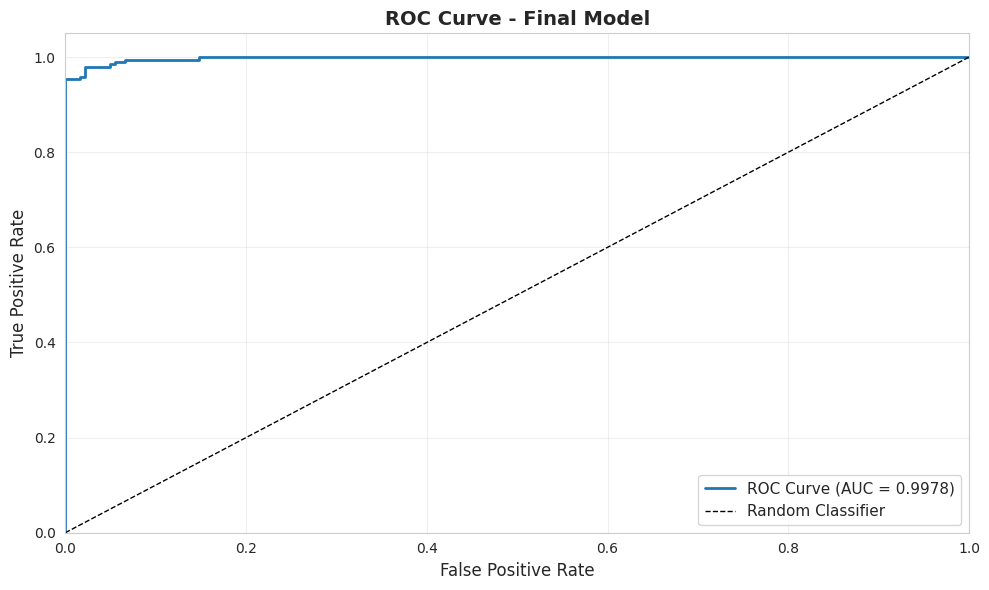

In [ ]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba_final)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC = {test_auc_final:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Final Model', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

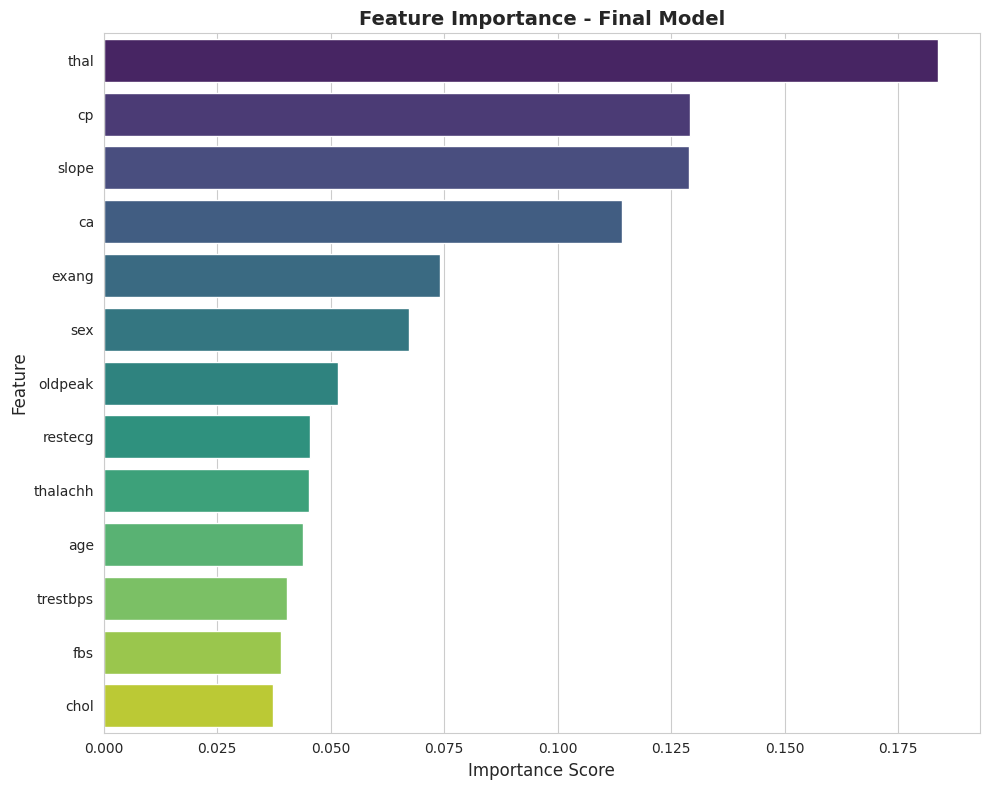


Top 5 Most Important Features:
   feature  importance
12    thal    0.183830
2       cp    0.129051
10   slope    0.128926
11      ca    0.114123
8    exang    0.073990


In [ ]:
# Feature Importance
feature_importance = pd.DataFrame({'feature': X.columns,'importance': final_model.feature_importances_}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
plt.title('Feature Importance - Final Model', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features:")
print(feature_importance.head())

##  Save Model and Scaler

In [ ]:
# Save the trained model
model_filename = 'xgboost_heart_disease_model.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(final_model, file)
print(f"✓ Model saved to: {model_filename}")

# Save the scaler
scaler_filename = 'scaler.pkl'
with open(scaler_filename, 'wb') as file:
    pickle.dump(scaler, file)
print(f"✓ Scaler saved to: {scaler_filename}")

# Save feature names for reference
feature_names = {'features': list(X.columns)}
features_filename = 'feature_names.pkl'
with open(features_filename, 'wb') as file:
    pickle.dump(feature_names, file)
print(f"✓ Feature names saved to: {features_filename}")

✓ Model saved to: xgboost_heart_disease_model.pkl
✓ Scaler saved to: scaler.pkl
✓ Feature names saved to: feature_names.pkl


##  Test Saved Model

In [ ]:
# Load saved model and scaler
with open('xgboost_heart_disease_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

with open('scaler.pkl', 'rb') as file:
    loaded_scaler = pickle.load(file)

print("✓ Model and scaler loaded successfully!")

✓ Model and scaler loaded successfully!


In [ ]:
# Create sample test data
sample_data = pd.DataFrame({
    'age': [55, 62, 45, 70],
    'sex': [1, 0, 1, 1],
    'cp': [0, 2, 1, 3],
    'trestbps': [130, 150, 120, 145],
    'chol': [240, 280, 210, 260],
    'fbs': [0, 1, 0, 1],
    'restecg': [1, 0, 1, 0],
    'thalachh': [160, 135, 175, 120],
    'exang': [0, 1, 0, 1],
    'oldpeak': [1.0, 2.5, 0.5, 2.0],
    'slope': [2, 1, 2, 0],
    'ca': [0, 1, 0, 2],
    'thal': [2, 3, 2, 3]
})

# Scale the data
sample_data_scaled = loaded_scaler.transform(sample_data)

# Make predictions
predictions = loaded_model.predict(sample_data_scaled)
probabilities = loaded_model.predict_proba(sample_data_scaled)[:, 1]

print("\n" + "="*60)
print("SAMPLE PREDICTIONS")
print("="*60)
for i in range(len(predictions)):
    status = 'Disease' if predictions[i] == 1 else 'No Disease'
    prob = probabilities[i] * 100
    print(f"Patient {i+1}: {status:12s} (Probability: {prob:5.2f}%)")
print("="*60)


SAMPLE PREDICTIONS
Patient 1: Disease      (Probability: 93.87%)
Patient 2: No Disease   (Probability:  1.34%)
Patient 3: Disease      (Probability: 99.81%)
Patient 4: No Disease   (Probability: 33.96%)
